## Table of contents

1. [**Inspecting Data**](#andmetesse_sissevaatamine)
2. [**Evaluation BertMorphTaggerV2**](#hindamine_v2)
3. [**Results BertMorphTaggerV2**](#tulemused_v2)

[end](#end)


### Conclusive evaluation results for the model

### Macro average metrics

> Note that the evaluation results are based on only the form label pairs, and thus do not take into account the POS tags.

| Model                                  | Accuracy | Precision | Recall | F1-score |
| -------------------------------------- | -------: | --------: | -----: | -------: |
| BertMorphTaggerV2                      |   94.66% |    42.07% | 39.34% |   40.55% |
| BertMorphTaggerV2 (lenient)            |   94.69% |    75.73% | 70.83% |   73.00% |
| BertMorphTaggerV2 (lenient, no others) |   95.47% |    94.66% | 89.25% |   91.61% |

Predictions outside the set of possible labels: **65/7886 (0.82%)**


### Imports


In [1]:
print("Test")

Test


In [2]:
import os
import evaluate
import re
import random
import math
import pandas as pd
import numpy as np
import estnltk, estnltk.converters, estnltk.taggers
import sklearn
import sklearn.metrics

from typing import Any, Tuple, Optional

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from tqdm import tqdm
from scripts.model.bert_morph_tagger import BertMorphTagger
from scripts.notebooks.NotebookFunctions import (
    _extract_prediction_from_layer,
    annotate_sentences_with_model,
    display_metrics_and_classification_report,
    plot_confusion_matrices,
    plot_true_vs_pred_by_inflection,
    display_examples,
    create_lenient_labels_and_split_counts_and_cases,
)

from scripts.config import (
    SEED,
    ROOT,
    DATA_DIR,
    ENC2017_ROOT,
    UD_ET_EDT_ROOT,
    HOMONYMS_ROOT,
    ENC2017_DIRS,
    UD_ET_EDT_DIRS,
    HOMONYMS_DIRS,
    OUTPUT_DIR,
    PLOTS_DIR,
    HOMONYMS_PLOTS_DIR,
    MODEL_DIR,
)

e:\Git_projects\EstNLTK\simpletransformers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a id='andmetesse_sissevaatamine'></a>


### Inspecting Data


In [3]:
overall_df = pd.read_parquet(
    HOMONYMS_DIRS["processed"] / "homonyms_overall_updated_sentences.parquet"
)

In [4]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]",[sg g],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


In [5]:
import numpy as np

# Convert list/array inflection types to tuples for consistent grouping
overall_df["label"] = overall_df["label"].apply(
    lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x
)

display(
    overall_df.groupby(["inflection_type", "label"])
    .size()
    .reset_index()
    .sort_values(by="inflection_type")
)

,inflection_type,label,0
0,1,"(sg g,)",1232
1,1,"(sg n,)",764
2,16,"(sg g,)",1080
3,16,"(sg n,)",890
4,17,"(sg g,)",524
5,17,"(sg n,)",791
6,17,"(sg p,)",609
7,19,"(adt,)",94
8,19,"(sg g,)",1621
9,19,"(sg p,)",281


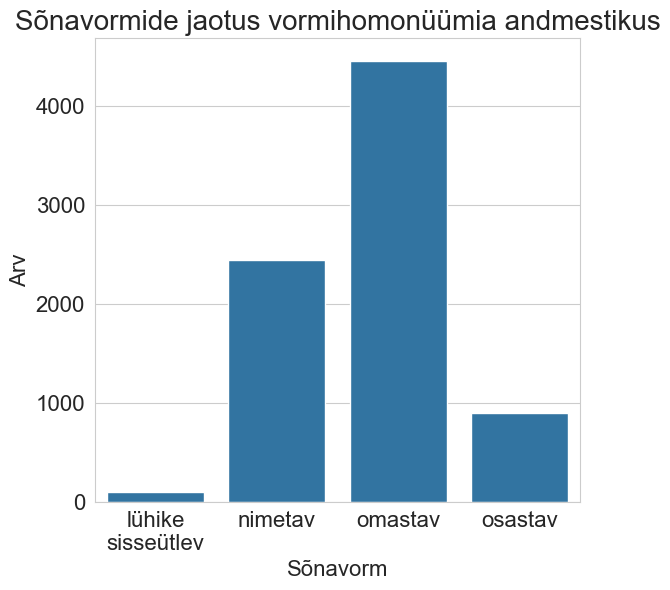

INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\Admin\AppData\Local\Temp\ipykernel_31564\215362590.py:38: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.countplot(


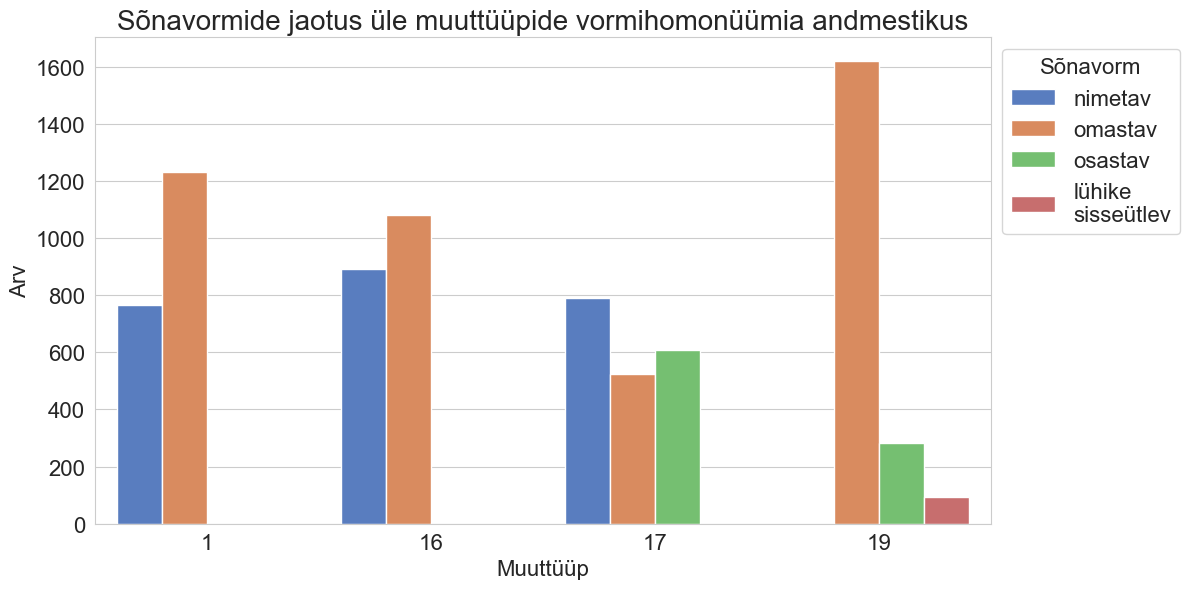

In [ ]:
overall_df["label_str"] = overall_df["label"].apply(lambda x: x[0])

# Rename the labels for better readability in plots
label_mapping = {
    "sg n": "nimetav",
    "sg g": "omastav",
    "sg p": "osastav",
    "adt": "lühike\nsisseütlev",
}
overall_df["label_str"] = (
    overall_df["label_str"].map(label_mapping).fillna(overall_df["label_str"])
)

# Plot label distribution
sns.set_style("whitegrid")
plt.figure(figsize=(6, 6))
sns.countplot(
    data=overall_df,
    x="label_str",
    order=sorted(overall_df["label_str"].dropna().unique()),
)
plt.title("Sõnavormide jaotus vormihomonüümia andmestikus", fontsize=20)
plt.xlabel("Sõnavorm", fontsize=16)
plt.ylabel("Arv", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "overall_label_distribution.png"),
    dpi=300,
)
plt.show()

# Plot label distribution across inflection types
sns.set_style("whitegrid")
palette = sns.color_palette("muted")
plt.figure(figsize=(12, 6))
sns.countplot(
    data=overall_df,
    x="inflection_type",
    hue="label_str",
    palette=palette,
    order=sorted(overall_df["inflection_type"].dropna().unique()),
)
plt.title("Sõnavormide jaotus üle muuttüüpide vormihomonüümia andmestikus", fontsize=20)
plt.xlabel("Muuttüüp", fontsize=16)
plt.ylabel("Arv", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(
    title="Sõnavorm",
    bbox_to_anchor=(1, 1),
    loc="upper left",
    fontsize=16,
    title_fontsize=16,
)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "label_distribution_by_inflection_type.png"),
    dpi=300,
)
plt.show()

In [ ]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]","(sg g,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


<a id='hindamine_v2'></a>


### Evaluation BertMorphTaggerV2


In [6]:
# Define model to use for annotation
model_path = "../models/NER_mudel_v2/"
model_name = "BertMorphTaggerV2"
df_output_csv_path = str(
    HOMONYMS_DIRS["annotations"] / "homonyms_annotations_Bert_morph_V2.csv"
)

In [ ]:
results_df = annotate_sentences_with_model(
    input_df=overall_df,
    model_name=model_path,
    output_csv_path=df_output_csv_path,
    progress_desc="Evaluating BertMorphTaggerV2 on homonyms dataset",
)

Evaluating BertMorphTaggerV2 on homonyms dataset: 100%|██████████| 7886/7886 [07:35<00:00, 17.30it/s]


In [ ]:
display(results_df.head())

,sentence,word,word_span,true_label,pred_label,ambiguous,num,inflection_type
0,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",sg n,sg n,False,1,1
1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"(20, 27)",sg n,sg n,False,1,1
2,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"(51, 60)",sg n,sg n,False,1,1
3,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"(16, 20)",sg n,sg n,False,1,1
4,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"(0, 7)",sg g,sg g,False,1,1


<a id='tulemused_v2'></a>


### Results BertMorphTaggerV2


In [7]:
# Load results dataframe
results_df = pd.read_csv(
    df_output_csv_path,
    index_col=False,
)

results_df_split, results_df_filtered = (
    create_lenient_labels_and_split_counts_and_cases(
        results_df, "true_label", "pred_label"
    )
)

results_df_filtered_possibles = results_df_filtered[
    (results_df_filtered["true_case_lenient"] != "other")
    & (results_df_filtered["pred_case_lenient"] != "other")
]

print(f"{model_name} results:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient):")
display_metrics_and_classification_report(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient, excluding 'other'):")
display_metrics_and_classification_report(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)

# Count cases where "other" was predicted and the proportion of those out of all predictions
other_pred_count = (results_df_filtered["pred_case_lenient"] == "other").sum()
total_pred_count = len(results_df_filtered)
print(
    f'\nNumber of "other" cases: {other_pred_count} out of {total_pred_count} ({other_pred_count / total_pred_count:.2%})'
)

# Count how many unique classes were predicted outside of the set of possible classes
possible_classes = set(results_df_split["true_case"].unique())
predicted_classes = set(results_df_split["pred_case"].unique())
predicted_outside_possible = predicted_classes - possible_classes
print(
    f"\nPredicted classes outside of possible set: {predicted_outside_possible} (count: {len(predicted_outside_possible)})"
)

BertMorphTaggerV2 results:
Overall results
Accuracy:  94.66%
Precision: 42.07%
Recall:    39.34%
F1-score:  40.55%

BertMorphTaggerV2 results (lenient):
Overall results
Accuracy:  94.69%
Precision: 75.73%
Recall:    70.83%
F1-score:  73.00%

BertMorphTaggerV2 results (lenient, excluding 'other'):
Overall results
Accuracy:  95.47%
Precision: 94.66%
Recall:    89.25%
F1-score:  91.61%

Number of "other" cases: 65 out of 7886 (0.82%)

Predicted classes outside of possible set: {'me', nan, 'o'} (count: 3)


In [5]:
# Print classification reports
print(f"{model_name} classification report:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2 classification report:
Overall results - Classification Report
              precision    recall  f1-score   support

           -       0.00      0.00      0.00         0
         adt       0.96      0.74      0.84        94
          me       0.00      0.00      0.00         0
           o       0.00      0.00      0.00         0
        pl g       0.00      0.00      0.00         0
        pl p       0.00      0.00      0.00         0
        sg g       0.96      0.98      0.97      4457
        sg n       0.96      0.91      0.94      2445
        sg p       0.90      0.90      0.90       890

    accuracy                           0.95      7886
   macro avg       0.42      0.39      0.41      7886
weighted avg       0.95      0.95      0.95      7886



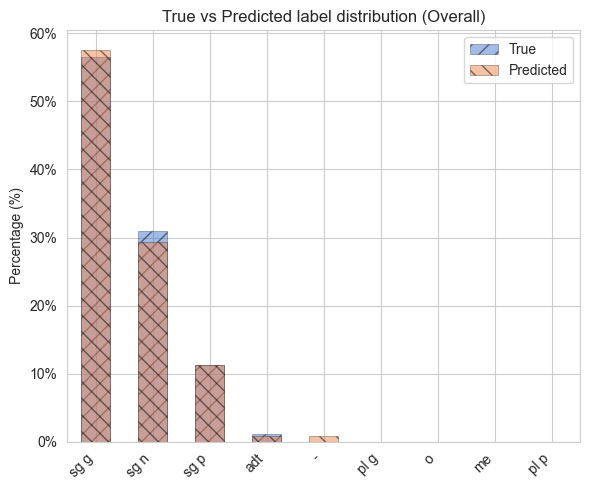

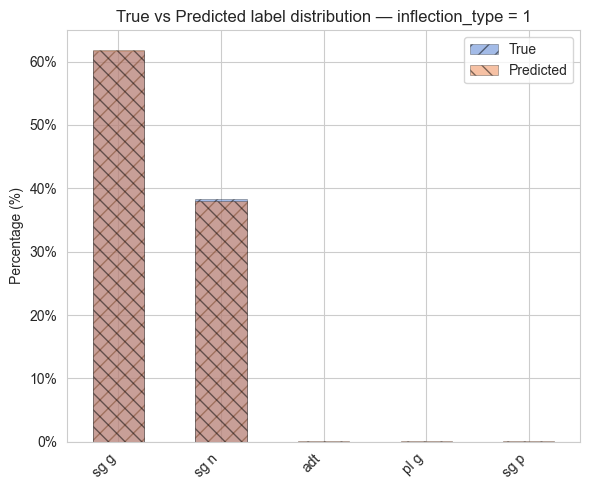

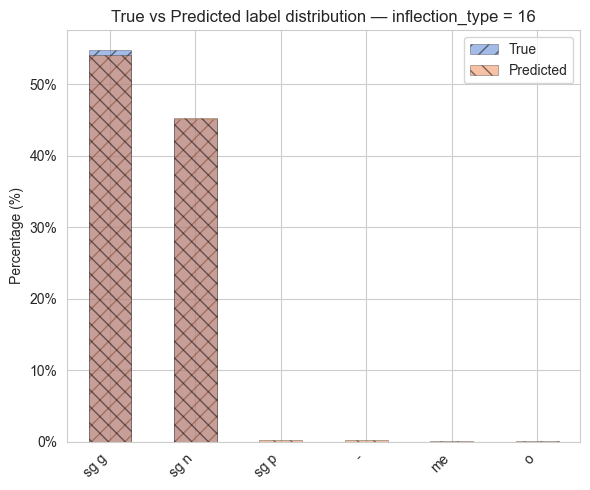

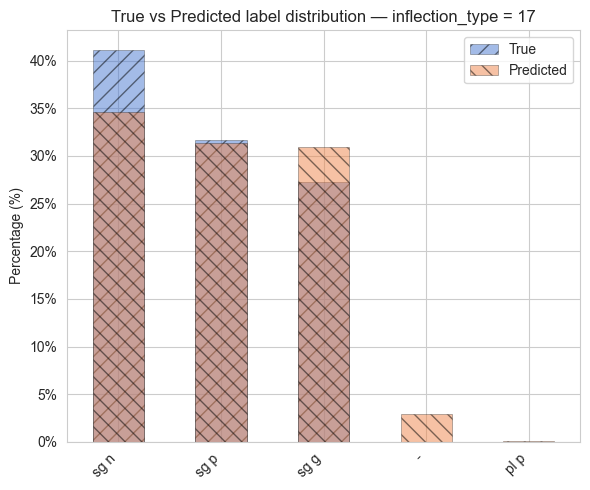

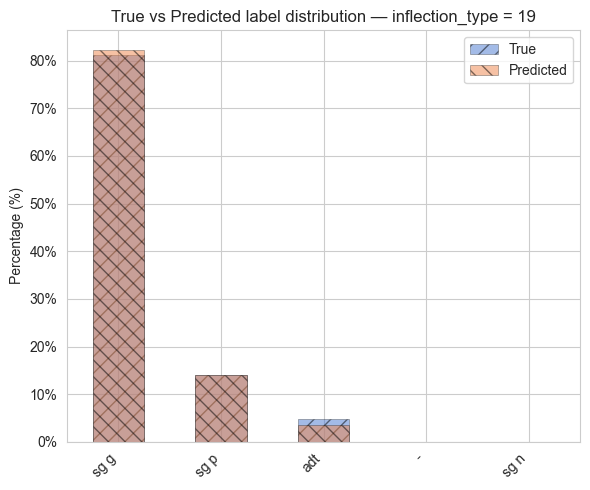

In [6]:
plot_true_vs_pred_by_inflection(
    results_df,
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar",
)

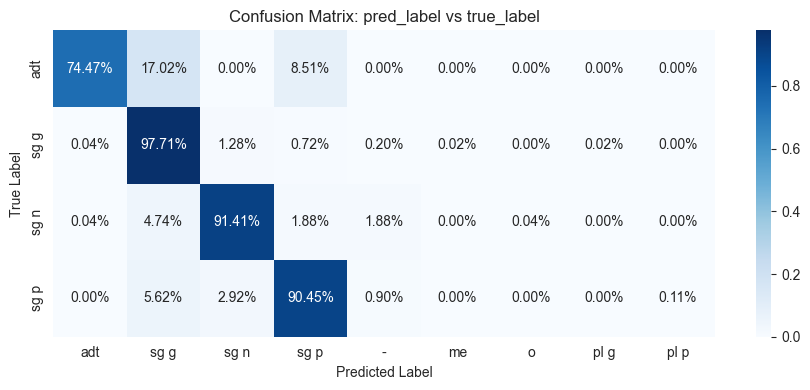

Confusion Matrix: pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -     63       0.80              True              0
1                   me      1       0.01              True              0
2                    o      1       0.01              True              0
3                 pl g      1       0.01              True              0
4                 pl p      1       0.01              True              0
Sum of true labels count: 7886


In [7]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    fig_size=(9, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM.png"),
    significant_pred_threshold_pct=0,
)

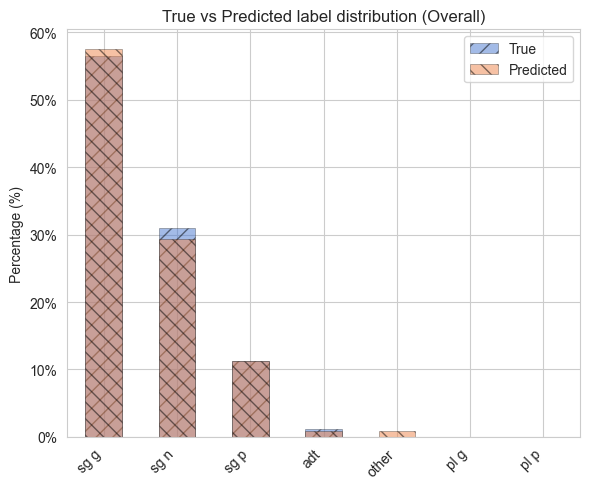

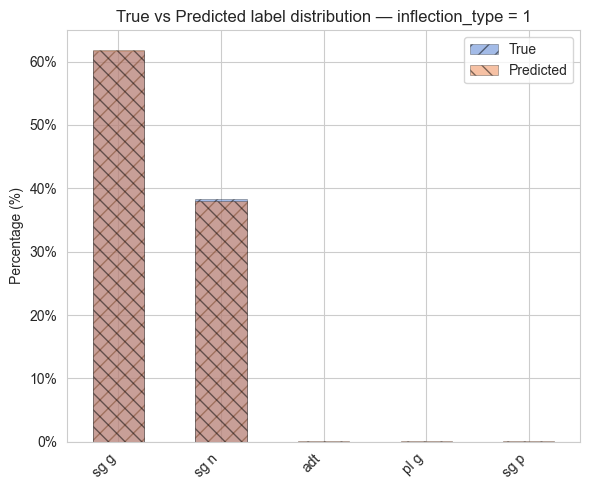

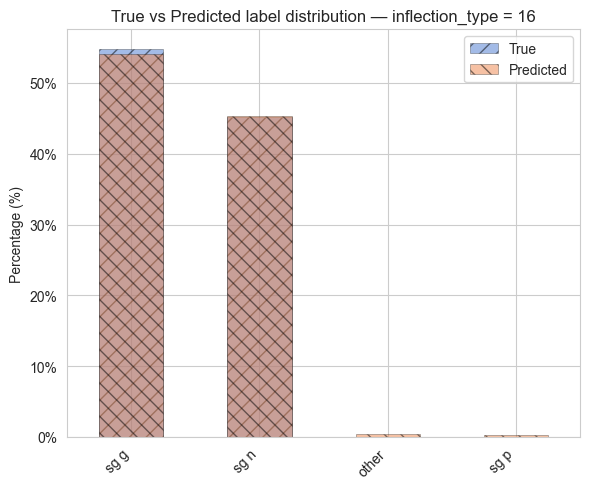

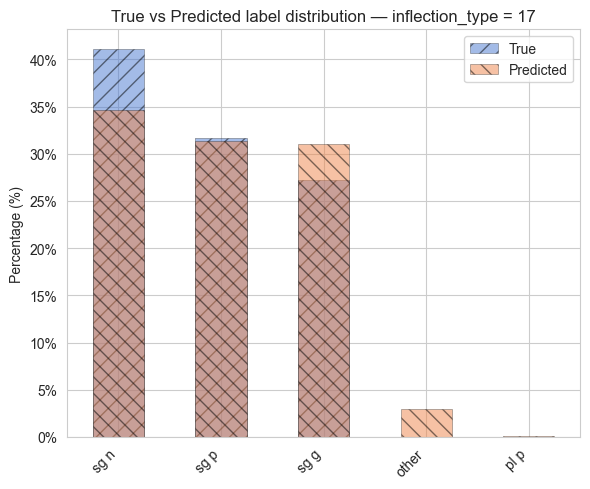

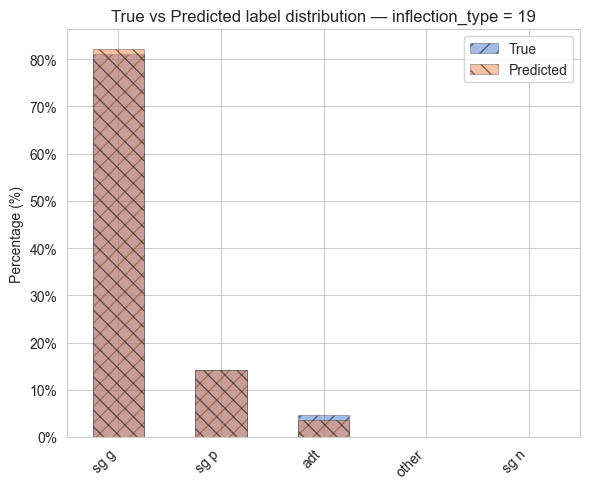

In [8]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_label_lenient",
    pred_col="pred_label_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_lenient_bar",
)

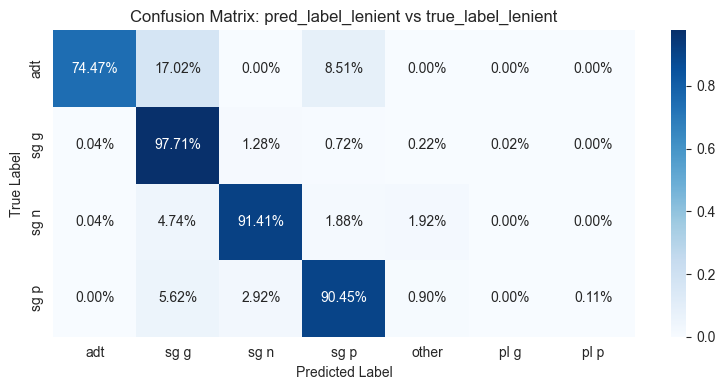

Confusion Matrix: pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other     65       0.82              True              0
1                 pl g      1       0.01              True              0
2                 pl p      1       0.01              True              0
Sum of true labels count: 7886


In [9]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    fig_size=(8, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient.png"),
    significant_pred_threshold_pct=0,
)

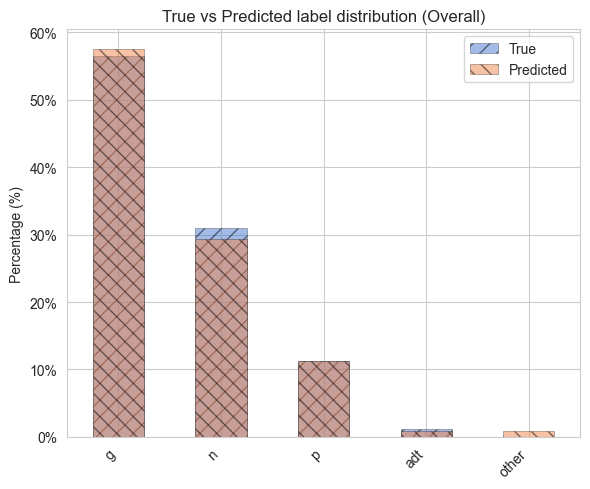

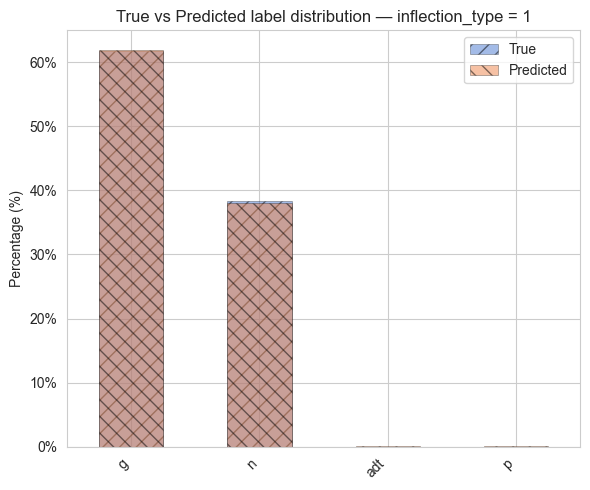

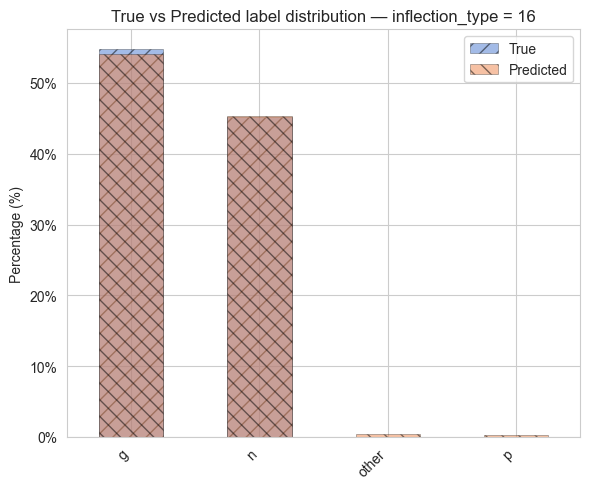

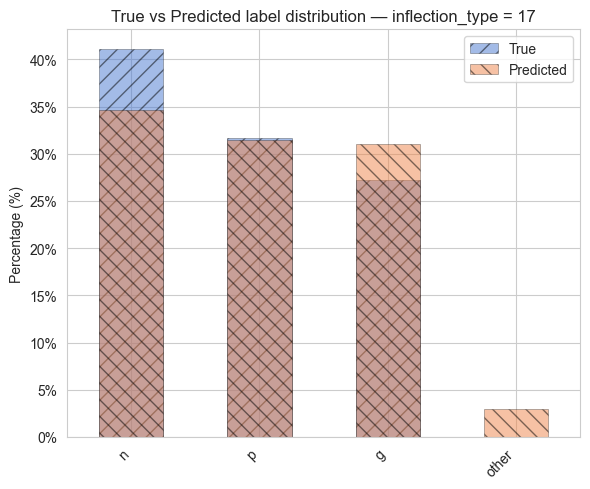

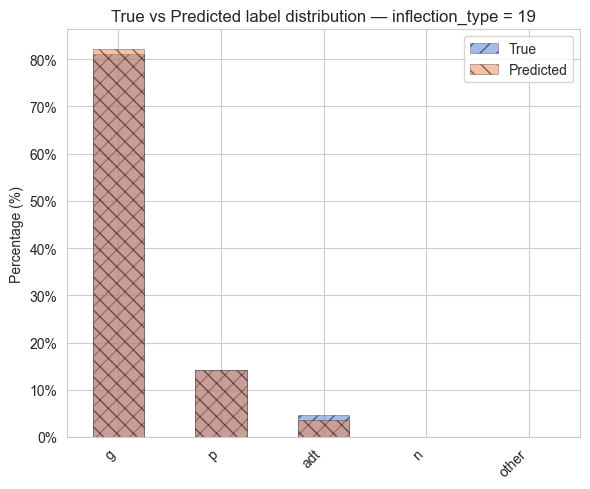

In [10]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case",
)

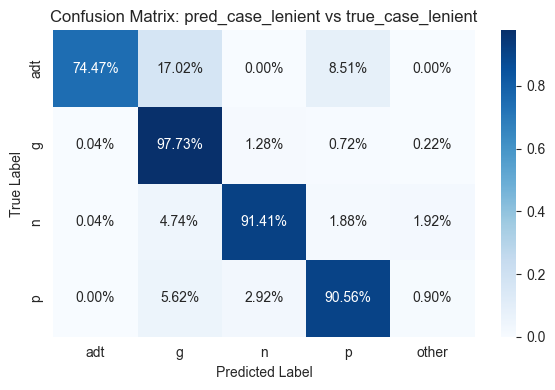

Confusion Matrix: pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other     65       0.82              True              0
Sum of true labels count: 7886


In [11]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case.png"
    ),
    significant_pred_threshold_pct=0,
)

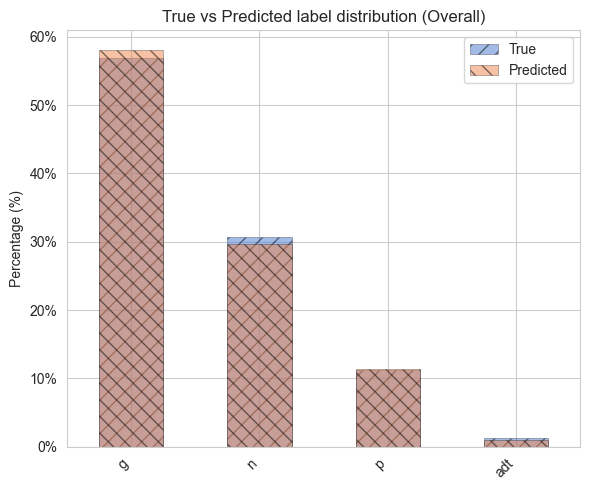

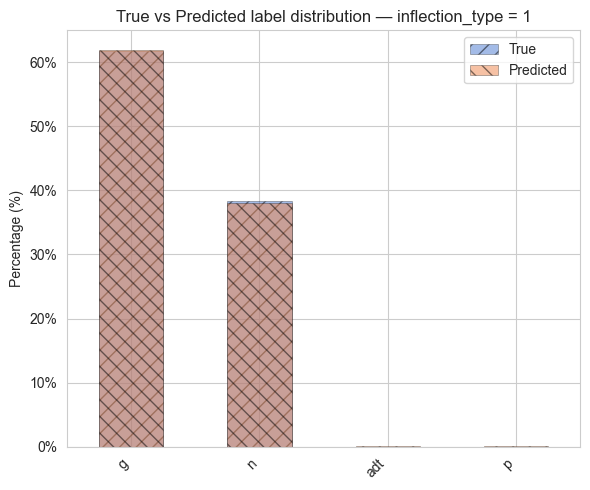

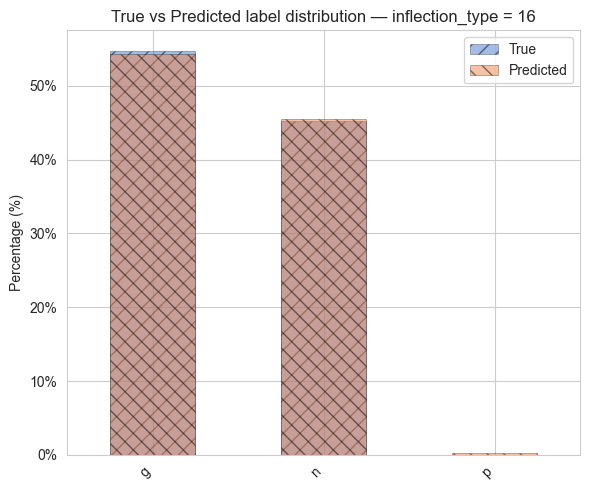

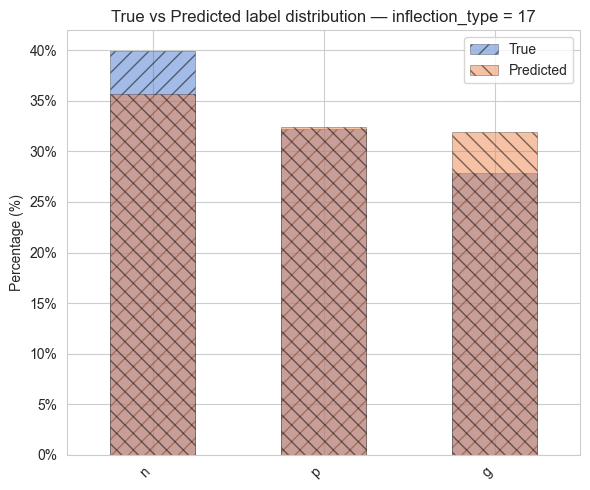

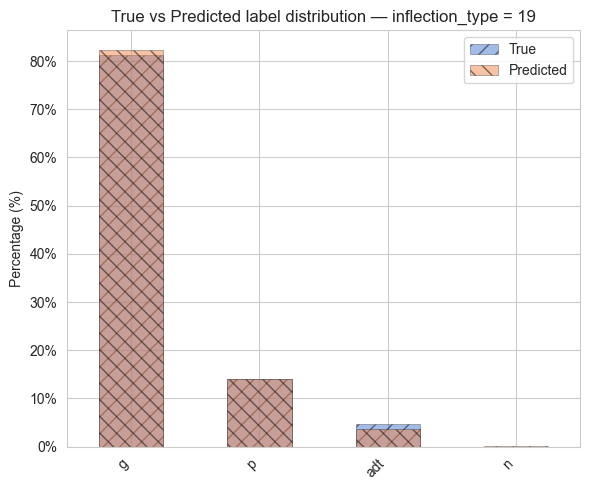

In [12]:
plot_true_vs_pred_by_inflection(
    results_df_filtered_possibles,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case_possibles",
)

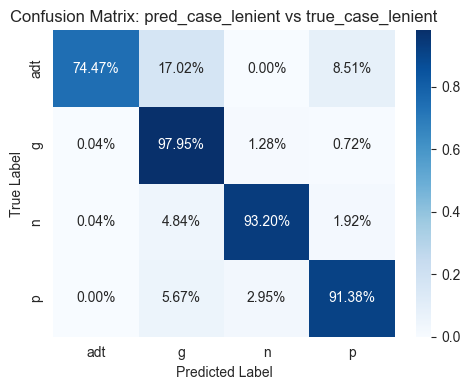

In [13]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(5, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_possibles.png"
    ),
    significant_pred_threshold_pct=0,
)

In [14]:
# Generate results per inflection type
print(f"{model_name} results per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

BertMorphTaggerV2 results per inflection type:
inflection_type=1
Accuracy:  97.09%
Precision: 97.24%
Recall:    97.09%
F1-score:  97.17%
inflection_type=16
Accuracy:  96.85%
Precision: 97.45%
Recall:    96.85%
F1-score:  97.15%
inflection_type=17
Accuracy:  86.95%
Precision: 90.30%
Recall:    86.95%
F1-score:  88.26%
inflection_type=19
Accuracy:  97.49%
Precision: 97.58%
Recall:    97.49%
F1-score:  97.47%


In [15]:
# Generate classification reports per inflection type
print(f"{model_name} classification reports per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=False,
    show_classification_report=True,
)

BertMorphTaggerV2 classification reports per inflection type:
inflection_type=1 - Classification Report
              precision    recall  f1-score   support

         adt       0.00      0.00      0.00         0
        pl g       0.00      0.00      0.00         0
        sg g       0.98      0.98      0.98      1232
        sg n       0.97      0.96      0.96       764
        sg p       0.00      0.00      0.00         0

    accuracy                           0.97      1996
   macro avg       0.39      0.39      0.39      1996
weighted avg       0.97      0.97      0.97      1996

inflection_type=16 - Classification Report
              precision    recall  f1-score   support

           -       0.00      0.00      0.00         0
          me       0.00      0.00      0.00         0
           o       0.00      0.00      0.00         0
        sg g       0.98      0.97      0.97      1080
        sg n       0.97      0.97      0.97       890
        sg p       0.00      0.00      

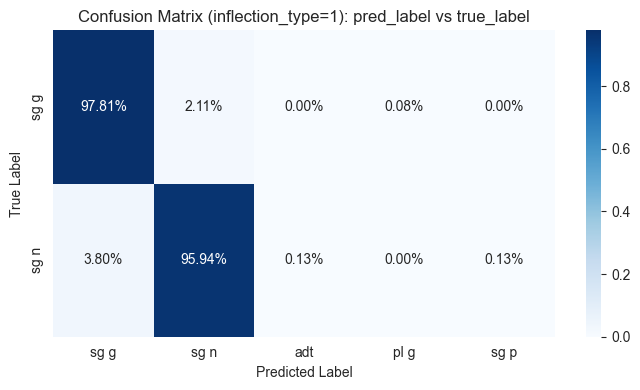

Confusion Matrix (inflection_type=1): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.05              True              0
1                 pl g      1       0.05              True              0
2                 sg p      1       0.05              True              0
Sum of true labels count: 1996


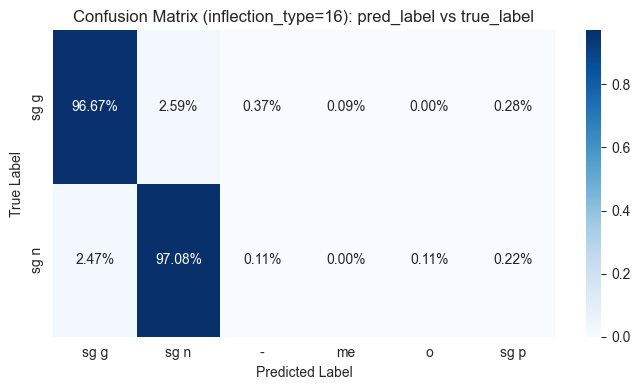

Confusion Matrix (inflection_type=16): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -      5       0.25              True              0
1                 sg p      5       0.25              True              0
2                   me      1       0.05              True              0
3                    o      1       0.05              True              0
Sum of true labels count: 1970


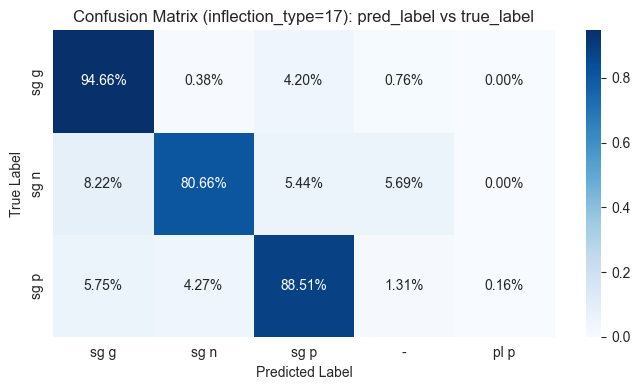

Confusion Matrix (inflection_type=17): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -     57       2.96              True              0
1                 pl p      1       0.05              True              0
Sum of true labels count: 1924


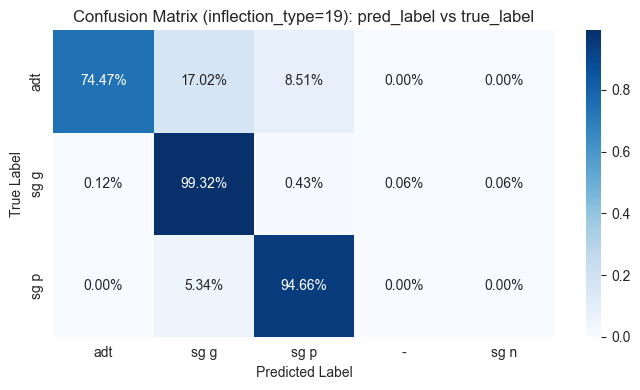

Confusion Matrix (inflection_type=19): pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -      1       0.05              True              0
1                 sg n      1       0.05              True              0
Sum of true labels count: 1996


In [16]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    fig_size=(7, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_infl.png"),
    significant_pred_threshold_pct=0,
)

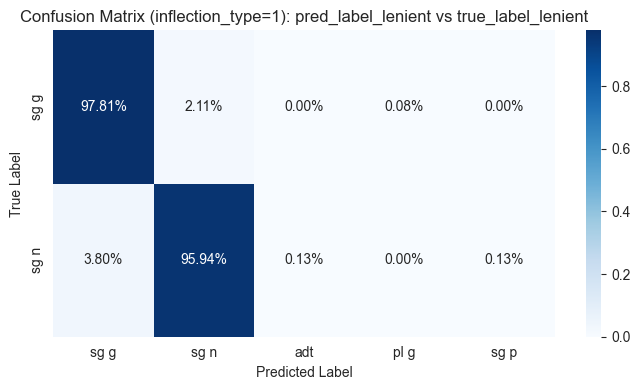

Confusion Matrix (inflection_type=1): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.05              True              0
1                 pl g      1       0.05              True              0
2                 sg p      1       0.05              True              0
Sum of true labels count: 1996


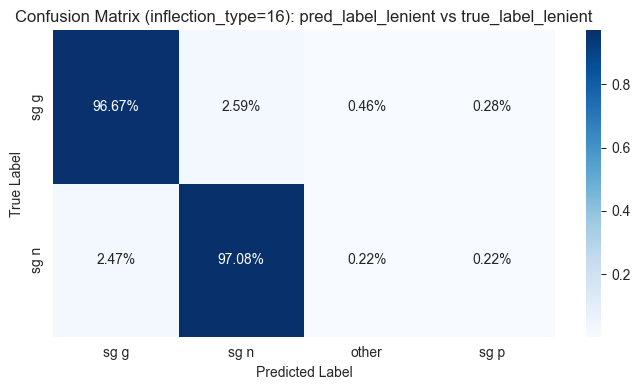

Confusion Matrix (inflection_type=16): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      7       0.36              True              0
1                 sg p      5       0.25              True              0
Sum of true labels count: 1970


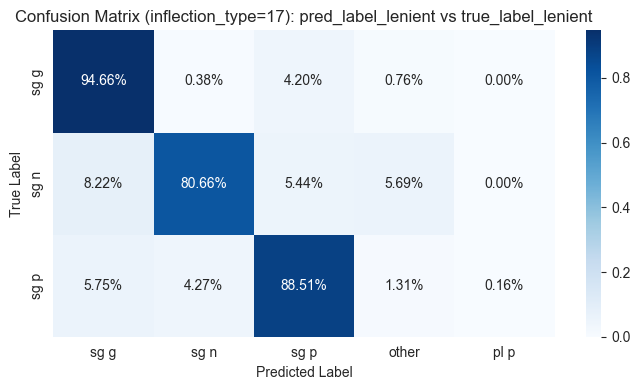

Confusion Matrix (inflection_type=17): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other     57       2.96              True              0
1                 pl p      1       0.05              True              0
Sum of true labels count: 1924


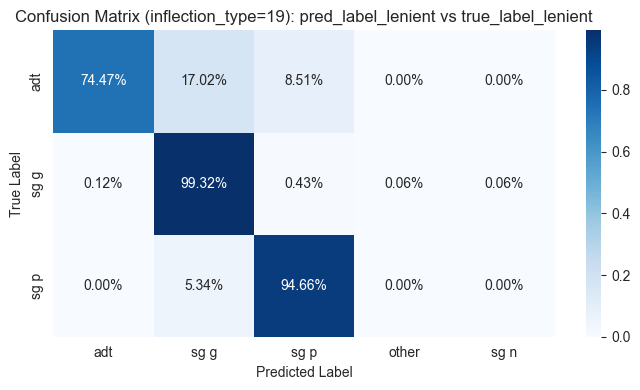

Confusion Matrix (inflection_type=19): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      1       0.05              True              0
1                 sg n      1       0.05              True              0
Sum of true labels count: 1996


In [17]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    group_col="inflection_type",
    fig_size=(7, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

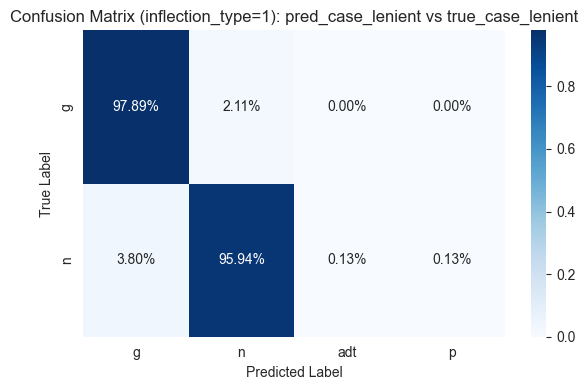

Confusion Matrix (inflection_type=1): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.05              True              0
1                    p      1       0.05              True              0
Sum of true labels count: 1996


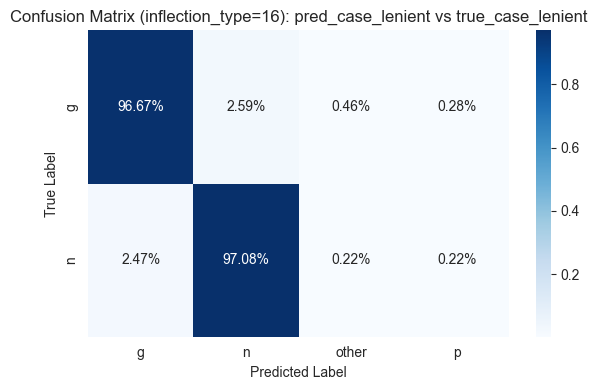

Confusion Matrix (inflection_type=16): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other      7       0.36              True              0
1                    p      5       0.25              True              0
Sum of true labels count: 1970


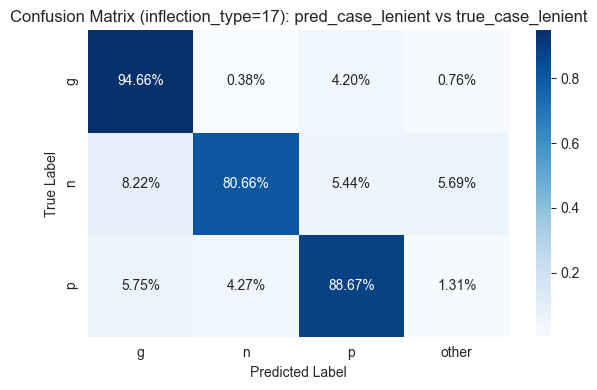

Confusion Matrix (inflection_type=17): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other     57       2.96              True              0
Sum of true labels count: 1924


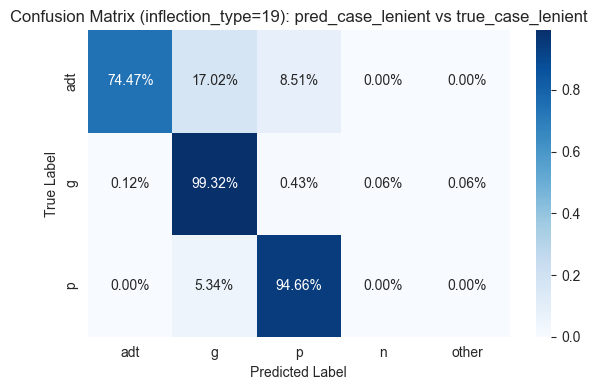

Confusion Matrix (inflection_type=19): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    n      1       0.05              True              0
1                other      1       0.05              True              0
Sum of true labels count: 1996


In [18]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

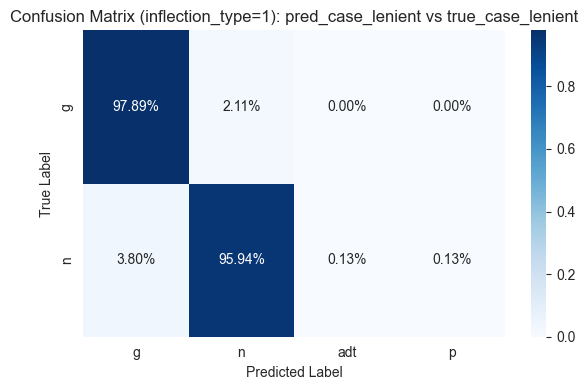

Confusion Matrix (inflection_type=1): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      1       0.05              True              0
1                    p      1       0.05              True              0
Sum of true labels count: 1996


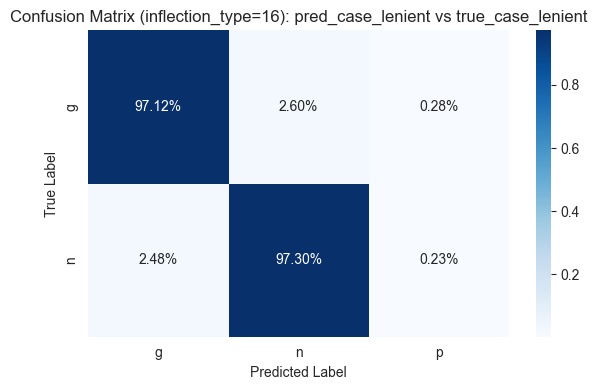

Confusion Matrix (inflection_type=16): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    p      5       0.25              True              0
Sum of true labels count: 1963


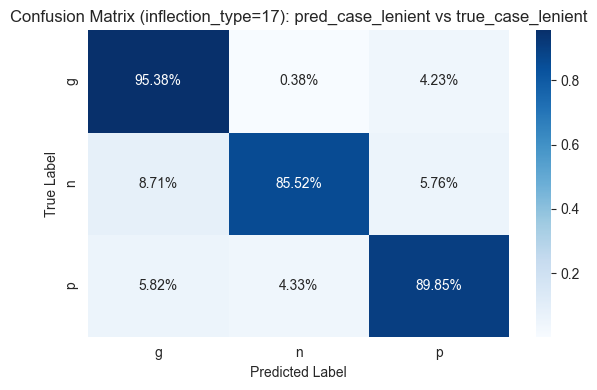

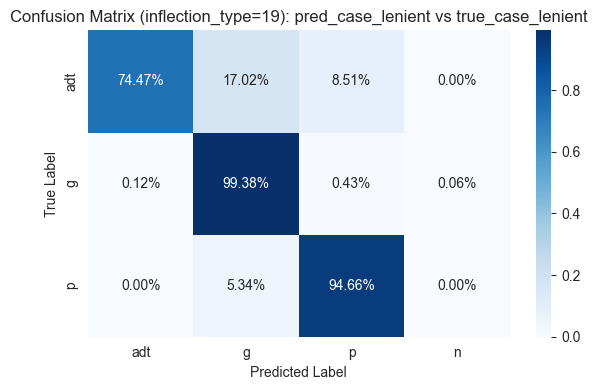

Confusion Matrix (inflection_type=19): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    n      1       0.05              True              0
Sum of true labels count: 1995


In [19]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR
        / model_name
        / f"{model_name}_CM_lenient_case_possibles_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

In [20]:
# Analyse results where BertMorphTagger predicted "sg g", but the true label was "adt"
sg_g_as_adt = results_df[
    (results_df["pred_label"] == "sg g") & (results_df["true_label"] == "adt")
]
print(sg_g_as_adt["inflection_type"].value_counts())
print(sg_g_as_adt["word"].value_counts().head(5))
display(sg_g_as_adt)
# Analyse results where BertMorphTagger predicted "sg p", but the true label was "adt"
sg_p_as_adt = results_df[
    (results_df["pred_label"] == "sg p") & (results_df["true_label"] == "adt")
]
print(sg_p_as_adt["inflection_type"].value_counts())
print(sg_p_as_adt["word"].value_counts().head(5))
display(sg_p_as_adt)

inflection_type
19    16
Name: count, dtype: int64
word
mikrofoni      2
gümnaasiumi    2
restorani      2
muuseumi       2
Washingtoni    1
Name: count, dtype: int64


,sentence,word,word_span,true_label,pred_label,ambiguous,num,inflection_type
3002,"""Ühe Euroopa sõidu ajal, kui arvati, et see idarahvas on natuke rumal, ja taheti presidendile tõlki, ütles Meri mikrofoni inglise keeles, et tal on vaja küsimusi, mitte tõlki!"" lausub 7. klassi poiss Tõnis.",mikrofoni,"(np.int64(112), np.int64(121))",adt,sg g,False,1,19
3013,"Samas on kõik uue kodu lähistel asuvad koolid sellised, mis võtavad gümnaasiumi vastu katsetega.",gümnaasiumi,"(np.int64(68), np.int64(79))",adt,sg g,False,1,19
3248,Kolkjasse Kala-Sibula restorani jõudmiseks kulub tallinlasel umbes kolm ja pool tundi.,restorani,"(np.int64(22), np.int64(31))",adt,sg g,False,1,19
3497,Hiljem tuleb tunnussõnaga numbri valimiseks vajutada aparaadi küljel olevale nupule ning öelda aparaadi või hands-free mikrofoni tunnussõna ning telefon valibki soovitava numbri.,mikrofoni,"(np.int64(119), np.int64(128))",adt,sg g,False,1,19
3527,Ajalehe Ha'aretz teatel sõidab Peres Cairosse neljapäeval enne järgmise nädala visiiti Washingtoni kõnelustele USA välisministri Colin Powelliga.,Washingtoni,"(np.int64(87), np.int64(98))",adt,sg g,False,1,19
3532,"Moskva teatas kavatusest 540 km pikkune piir sulgeda läinud nädalal, reageerides sellega tshetsheeni islamivõitlejate tungimisele üle piiri Dagestani ja pommiplahvatustele Venemaal.",Dagestani,"(np.int64(140), np.int64(149))",adt,sg g,False,1,19
3550,"Tagantjärelegi on tal raske mõista, miks võtsid professoritest vangid leedulane Kezgailo ja lätlane Ošins endale suure riski : kui neil tekkis võimalus võtta haigla personali lisaks üks meditsiinitöötaja, valisid nad Laane.",personali,"(np.int64(165), np.int64(174))",adt,sg g,False,1,19
3572,"Warner Bros lükkas oktoobrist veebruari uue Arnold Schwarzeneggeri filmi ""Kaasnevad purustused"" (Collateral damage) esilinastuse, sest seal on juttu õhkulastud pilvelõhkujast.",veebruari,"(np.int64(30), np.int64(39))",adt,sg g,False,1,19
3763,"Raha, sõjatehnika ja instruktorid lähevad Indoneesiasse, Usbekistani, Nepali, Jordaaniasse, Pakistani, Kasahstani, Kõrgõzstani ja Usbekistani, kinnitas kaitseministeeriumi esindaja.",Usbekistani,"(np.int64(130), np.int64(141))",adt,sg g,False,1,19
3823,"Pärast viimast sõda asus ta tööle Tallinna, alul loodusteaduste muuseumi, hiljem töötas Õpetajate Täiendusinstituudis ja Tallinna Pedagoogilises Instituudis.",muuseumi,"(np.int64(64), np.int64(72))",adt,sg g,False,1,19


inflection_type
19    8
Name: count, dtype: int64
word
restorani    2
alkoholi     2
telefoni     1
terminali    1
tribunali    1
Name: count, dtype: int64


,sentence,word,word_span,true_label,pred_label,ambiguous,num,inflection_type
2981,"Pealinna tänavail ringi uidates tungisid neist kolm restorani, kus lükkasid ümber laudu ja toole ning mugisid porgandeid.",restorani,"(np.int64(52), np.int64(61))",adt,sg p,False,1,19
3113,"Ameerika ülikoolid püüavad kaitsta verisulis elluastujaid alkoholi uppumast, Eesti kõrgkoolid seni mitte",alkoholi,"(np.int64(58), np.int64(66))",adt,sg p,False,1,19
3921,"""Eesti alkoholi suhtutakse üldiselt üleolevalt,"" räägib Tschakkar, ""tavaliselt võetakse pidudele ükskõik mis jooki, peaasi, et välismaine.",alkoholi,"(np.int64(7), np.int64(15))",adt,sg p,False,1,19
7088,"Või läheks hiina restorani sööma, härra Allikmaa?",restorani,"(np.int64(17), np.int64(26))",adt,sg p,False,2,19
7456,Väga ilusasti ütles see daam telefoni.,telefoni,"(np.int64(29), np.int64(37))",adt,sg p,False,2,19
7664,Foto : Rauno Volmar Estonian Air hakkab alates 25. märtsist lendama Pariisi Charles de Gaulle'i lennujaama terminali 1 senise terminali 2B asemel.,terminali,"(np.int64(107), np.int64(116))",adt,sg p,False,2,19
7808,"Lõoke olevat öelnud, et ""kõik kommunistid tuleb hävitada"", seda pandi talle süüks ning kõik kätte saadud rakkelastest omakaitselased toodi tribunali tunnistama.",tribunali,"(np.int64(139), np.int64(148))",adt,sg p,False,2,19
7874,"""Pidage rangelt kinni raportiteks ette nähtud kellaaegadest!"" kõmistas ta mikrofoni, ise samal ajal ""külalistetoas"" temperatuuri tõstes.",mikrofoni,"(np.int64(74), np.int64(83))",adt,sg p,False,2,19


BertMorphTaggerV2 pakub lühikese sisseütleva (`adt`) asemel omastava (`sg g`), osastava (`sg p`) või nimetava (`sg n`) käände vormi. Kõik näited on muuttüübist 19.


In [21]:
# Analyse results where BertMorphTagger predicted "sg n", but the true label was "sg g"
sg_n_as_sg_g = results_df[
    (results_df["pred_label"] == "sg n") & (results_df["true_label"] == "sg g")
]
print(sg_n_as_sg_g["inflection_type"].value_counts())
print(sg_n_as_sg_g["word"].value_counts().head(5))
display(sg_n_as_sg_g)
# Analyse results where BertMorphTagger predicted "sg p", but the true label was "sg g"
sg_p_as_sg_g = results_df[
    (results_df["pred_label"] == "sg p") & (results_df["true_label"] == "sg g")
]
print(sg_p_as_sg_g["inflection_type"].value_counts())
print(sg_p_as_sg_g["word"].value_counts().head(5))
display(sg_p_as_sg_g)

inflection_type
16    28
1     26
17     2
19     1
Name: count, dtype: int64
word
Saku          5
korraldaja    2
aasta         2
juhataja      1
võitja        1
Name: count, dtype: int64


,sentence,word,word_span,true_label,pred_label,ambiguous,num,inflection_type
38,Andres Ülviste Paetisme - Pühapäeval läheb Eesti suveajale.,Ülviste,"(np.int64(7), np.int64(14))",sg g,sg n,False,1,1
103,56 spordiajakirjanikku 36 riigist valisid aasta spordiisiksuseks tänavuse Tour de France'i võitja Lance Armstrongi (USA).,võitja,"(np.int64(91), np.int64(97))",sg g,sg n,False,1,1
178,Võrumaa veterinaarkeskuse juhataja Neeme Truija arvates jääb neid tõenäoliselt alles kaks.,juhataja,"(np.int64(26), np.int64(34))",sg g,sg n,False,1,1
384,Halinga Puu raamatupidamises ei kajastu ka H & N Finantseerimisgrupi 264 386 dollari suurune nõue.,Halinga,"(np.int64(0), np.int64(7))",sg g,sg n,False,1,1
498,"Eks Kaubamaja kaubamärgiga opereerirva AS-i Veneetsia Kaupmees omaniku Eesti Talleksi juhataja Ivar Simson ütles, et Eks Kaubamaja kavatseb likviiduskriisist üle saada kaubavarude mahamüümisega.",Veneetsia,"(np.int64(44), np.int64(53))",sg g,sg n,False,1,1
516,"Tallinna, Tartu, Pärnu ja mõned muud on juba käes.",Tartu,"(np.int64(10), np.int64(15))",sg g,sg n,False,1,1
642,Ürituse korraldaja Merle Ljubimova sõnul võivad mõned jalutuskäiketenduse stseenid libahuntide ja kummitustega publikut ehmatadagi.,korraldaja,"(np.int64(8), np.int64(18))",sg g,sg n,False,1,1
834,EPMÜ avalikkussuhete korraldaja Katrin Uindi sõnul suurt tseremooniat ei korraldata.,korraldaja,"(np.int64(21), np.int64(31))",sg g,sg n,False,1,1
869,Jäähokiliigas NHL alistas Ottawa Senators 4 : 1 Colorado Avalanche.,Ottawa,"(np.int64(26), np.int64(32))",sg g,sg n,False,1,1
1024,"Heati esitosinasse avamängus Atlanta Hawksi vastu valiti tagamängijad Tim Hardaway, Sasha Danilovic, Dan Majerle, Voshon Lenard, Gary Grant, ründajad Kurt Thomas, Keith Askins, Mark Strickland, Ed Pinckney, keskmängijad Alonzo Mourning, P.J Brown ja Isaac Austin.",Atlanta,"(np.int64(29), np.int64(36))",sg g,sg n,False,1,16


inflection_type
17    22
19     7
16     3
Name: count, dtype: int64
word
elu      4
raha     4
kahju    3
vaba     2
osa      2
Name: count, dtype: int64


,sentence,word,word_span,true_label,pred_label,ambiguous,num,inflection_type
1317,"Aastatel 1999-2002 vargustega kokku 4,2 miljonit krooni kahju tekitanud jõugu käekiri oli robustne.",kahju,"(np.int64(56), np.int64(61))",sg g,sg p,False,1,16
1799,Ringkonnakohtu 12. novembri otsuse järgi peab Tartu linnavalitsus kannatanuks osutunud naisterahvale hüvitama talvises avariis sõiduautole Jaguar tekkinud kahju.,kahju,"(np.int64(155), np.int64(160))",sg g,sg p,False,1,16
2064,"Teine neiu soovib kaitseväelase elu läbi teha selleks, et hiljem asuda õppima Riigikaitse Akadeemiasse, rääkis Seppik.",elu,"(np.int64(32), np.int64(35))",sg g,sg p,False,1,17
2206,Õhtul külastasid kirikupead Haapsalu püha Maarja – Magdaleena kirikut.,püha,"(np.int64(37), np.int64(41))",sg g,sg p,False,1,17
2389,"Marks & Spencer näiteks ehitas oma maine Suurbritannias suures osas sellele, et klient võis ostetud kauba poodi tuua ja selle eest raha tagasi saada, ilma, et peaks vingus näoga müüjalt seda teenet välja lunima.",raha,"(np.int64(131), np.int64(135))",sg g,sg p,False,1,17
2514,""" Ta mõtleb ühe minuti kestnud kolme kilomeetri pikkust vaba langemist.",vaba,"(np.int64(56), np.int64(60))",sg g,sg p,False,1,17
2559,See maksis aga nelja inimese elu.,elu,"(np.int64(29), np.int64(32))",sg g,sg p,False,1,17
2583,"Juhtimiskeskus nagu kaptenisild Kuid ka pime kana leiab tera, ütleb kõnekäänd.",tera,"(np.int64(56), np.int64(60))",sg g,sg p,False,1,17
2602,"Seejärel anti luba kõigil laiali minna, kes tahtis, võis võtta tööst vaba päeva.",vaba,"(np.int64(69), np.int64(73))",sg g,sg p,False,1,17
2760,"Arstid kardavad, et tema ainus neer võis häda saada.",häda,"(np.int64(41), np.int64(45))",sg g,sg p,False,1,17


BertMorphTaggerV2 pakub omastava (`sg g`) asemel nimetava (`sg n`) käände vormi. Rohkem on vigu muuttüüpidel 16 ja 1.

Samuti pakub BertMorphTaggerV2 omastava (`sg g`) asemel osastava (`sg p`) käände vormi. Rohkem on vigu muuttüübil 17.


In [22]:
# Analyse results where BertMorphTagger predicted "sg g", but the true label was "sg n"
sg_g_as_sg_n = results_df[
    (results_df["pred_label"] == "sg g") & (results_df["true_label"] == "sg n")
]
print(sg_g_as_sg_n["inflection_type"].value_counts())
print(sg_g_as_sg_n["word"].value_counts().head(5))
display(sg_g_as_sg_n)

inflection_type
17    65
1     29
16    22
Name: count, dtype: int64
word
Eesti       11
sama         9
elu          5
juhataja     5
maja         4
Name: count, dtype: int64


,sentence,word,word_span,true_label,pred_label,ambiguous,num,inflection_type
180,Kõnealused valikukriteeriumid lisatakse artikli 5 lõike 1 punktis b osutatud lepingule ja on kõnealuse lepingu lahutamatu osa.,lahutamatu,"(np.int64(111), np.int64(121))",sg n,sg g,False,1,1
199,"Kauplustes 18 krooni maksva Shamtu šampooni (Fruity Power) reklaam oleks otsekui mõne imala armastusfilmi paroodia seltskond tüdrukuid käpib tualettruumis oma juukseid, misjärel minnakse rokikontserdile, kus võrgutatakse ära solist, kes Shamtu šampooniga pead pesnud neiu lavale kutsub ja talle naeratab...",paroodia,"(np.int64(106), np.int64(114))",sg n,sg g,False,1,1
449,Lootusrikkalt alanud spordikarjäärile tõmbas kriipsu raske küünarliigese vigastus.,raske,"(np.int64(53), np.int64(58))",sg n,sg g,False,1,1
466,"Kui ma olin ühe sellise ära joonud, siis mõtlesin, et aasta aega ei taha enam.",aasta,"(np.int64(54), np.int64(59))",sg n,sg g,False,1,1
518,"Püsivad rohusöötade saagid, proteiinirikka silo tehnoloogia ja mobiilse laudatehnika kättesaadavus ning põlvkondade pikkune kogemus võimaldavad edukalt majandada piimakarja.",tehnoloogia,"(np.int64(48), np.int64(59))",sg n,sg g,False,1,1
...,...,...,...,...,...,...,...,...
6778,"Aasta algusest on Ühispanga Elukindlustus kogunud 69, 3 miljonit krooni kindlustuspreemiaid, võrrelduna 2001. aasta sama perioodiga on preemiate maht kasvanud 51 protsenti.",sama,"(np.int64(116), np.int64(120))",sg n,sg g,False,2,17
6784,Sama seaduse § 6 kohaselt kinnitab arengukava koostamise ülesande ja tähtaja valitsus.,Sama,"(np.int64(0), np.int64(4))",sg n,sg g,False,2,17
6792,Mittelenduvate ainete määramine propioonhappes (E 280) II lisa 3. meetodi abil.,lisa,"(np.int64(58), np.int64(62))",sg n,sg g,False,2,17
6801,"Eestis elavad vene kodanikud on täielikku patiseisu sattunud - ühelt poolt protestitakse väidetavalt liiga rangete kodakondsusnõuete üle, teiselt poolt aga mõistetakse (kui mõistetakse), et Eesti kodakondsuseta ei saa nad ka Euroopa Liidu kodanikeks ega saa osa liidu kodanike privileegidest, näiteks vaba liikumise võimalusest.",vaba,"(np.int64(301), np.int64(305))",sg n,sg g,False,2,17


BertMorphTaggerV2 pakub nimetava (`sg n`) asemel omastava (`sg g`) käände vormi. Näited on muuttüüpidest 17, 1, 16. Sagedasemad vead on sõnadega "Eesti", "sama", "elu", "juhataja" ja "maja".


In [23]:
# Analyse results where BertMorphTagger predicted "sg g", but the true label was "sg p"
sg_g_as_sg_p = results_df[
    (results_df["pred_label"] == "sg g") & (results_df["true_label"] == "sg p")
]
print(sg_g_as_sg_p["inflection_type"].value_counts())
print(sg_g_as_sg_p["word"].value_counts().head(5))
display(sg_g_as_sg_p)
# Analyse results where BertMorphTagger predicted "sg n", but the true label was "sg p"
sg_n_as_sg_p = results_df[
    (results_df["pred_label"] == "sg n") & (results_df["true_label"] == "sg p")
]
print(sg_n_as_sg_p["inflection_type"].value_counts())
print(sg_n_as_sg_p["word"].value_counts().head(5))
display(sg_n_as_sg_p)

inflection_type
17    35
19    15
Name: count, dtype: int64
word
maja    5
raha    4
osa     3
elu     3
sõna    2
Name: count, dtype: int64


,sentence,word,word_span,true_label,pred_label,ambiguous,num,inflection_type
2020,"Müügil on eestlaste kuldraamatukogu ehk sada eesti elu enim mõjutatud raamatut, mille selgitasid üheaegselt välja president Lennart Meri õpetatud nõukogu ja raamatukogude lugejad.",elu,"(np.int64(51), np.int64(54))",sg p,sg g,False,1,17
2036,Autokasutuse piiramine kesklinnas peaks suunama vähemalt osa autokasutajatest muid liikumisvõimalusi kasutama.,osa,"(np.int64(57), np.int64(60))",sg p,sg g,False,1,17
2039,"Juba tegutsevate ettevõtete puhul on laenu pakkumine üks võimalus, aga kui riigil on ressurssi vähe, siis põhimõtteliselt on riigil võimalik asuda laenude tagaja rolli, võttes osa riskist enda kanda.",osa,"(np.int64(176), np.int64(179))",sg p,sg g,False,1,17
2092,"Vabandust, kui mõnel autoga puhkusel oleva linnaametnikul nüüd tuju rikkusin.""",tuju,"(np.int64(63), np.int64(67))",sg p,sg g,False,1,17
2099,"Omegaga oleme väga rahul, sest kuigi auto saab kõva vatti, on ta ekspluatatsioonikulud väikesed,"" ütles ta.",kõva,"(np.int64(47), np.int64(51))",sg p,sg g,False,1,17
2119,"Nii peab Gasol loovutama osa palgast ja talle jääb ""vaid"" 4 miljonit USD esimesel kolmel hooajal.",osa,"(np.int64(25), np.int64(28))",sg p,sg g,False,1,17
2144,"Läänemaal Ridala vallas karistas keskkonnainspektor 3000 krooni suuruse trahviga Aleksandrit (44), kellel ei olnud 600 kilo räime kohta esitada kala päritolu tõendavaid dokumente.",kilo,"(np.int64(119), np.int64(123))",sg p,sg g,False,1,17
2145,"PIC Eesti ASi peaspetsialist Jüri Teder kinnitas, et firma tehtud otstarbekuse uuring kinnitas 100-ruutkilomeetrise ala, kust tuleb valida 45 hektari suuruse hiidprügila lõplik asukoht.",ala,"(np.int64(116), np.int64(119))",sg p,sg g,False,1,17
2189,Nii saaks kodumaa majandus kena rahasüsti.,kena,"(np.int64(27), np.int64(31))",sg p,sg g,False,1,17
2308,"Köln võitis poolaja 41 : 28, kuid mängis siis suure edu maha ja oli veel minut enne lõppu taga 70 : 73.",edu,"(np.int64(52), np.int64(55))",sg p,sg g,False,1,17


inflection_type
17    26
Name: count, dtype: int64
word
raha    6
osa     5
elu     2
sõna    2
Huvi    1
Name: count, dtype: int64


,sentence,word,word_span,true_label,pred_label,ambiguous,num,inflection_type
2034,"FC Flora kukrusse voolab raha mängutulemustest sõltumata, seda küll ebastabiilselt, kuid ikkagi.",raha,"(np.int64(25), np.int64(29))",sg p,sg n,False,1,17
2076,"Taevaskoja kontserdiplats oli publikut tulvil, osa külalisi jälgis show'd metsa alt.",osa,"(np.int64(47), np.int64(50))",sg p,sg n,False,1,17
2143,"""Osa õpilasi on käinud Berliinis ja Viinis, aga Viljandis mitte,"" lausus ta.",Osa,"(np.int64(1), np.int64(4))",sg p,sg n,False,1,17
2151,"Kui osa terroriste oleks elusalt kinni võetud ja see oleks avalikkusele teada olnud, siis oleks nende üle tulnud korraldada kohtuprotsess, mis oleks maailmas äratanud suurt tähelepanu.",osa,"(np.int64(4), np.int64(7))",sg p,sg n,False,1,17
2172,"Et asi paljuski vaid ristikese pärast tehtud oli, näitab seegi, et riigieelarvest eraldati õpikute tarvis raha napilt - selleks aastaks saadi küsitud 230 asemel 198 krooni õpilase kohta.",raha,"(np.int64(106), np.int64(110))",sg p,sg n,False,1,17
2254,Mõnikord on häda ka loomadega.,häda,"(np.int64(12), np.int64(16))",sg p,sg n,False,1,17
2323,Huvi jätkub täpselt viieks minutiks.,Huvi,"(np.int64(0), np.int64(4))",sg p,sg n,False,1,17
2572,Või siis onu Oskarit.,onu,"(np.int64(9), np.int64(12))",sg p,sg n,False,1,17
2613,"Tshernomõrdin tunnistas, et esimese nelja kuuga õnnestus valitsusel täita eelarve tulude osa 64 protsendi ja kulude osa 70 protsendi ulatuses.",osa,"(np.int64(116), np.int64(119))",sg p,sg n,False,1,17
2632,"Tema sõnul tuleb paratamatult osa tööstusi sulgeda, sest tooret nii palju ei ole.",osa,"(np.int64(30), np.int64(33))",sg p,sg n,False,1,17


BertMorphTaggerV2 pakub osastava (`sg p`) asemel nimetava (`sg n`) või omastava (`sg g`) käände vormi. Näited on muutüüpidest 17 ja 19. Sagedasemad vead on sõnadega "raha", "maja", "osa", "elu" ja "sõna".


In [24]:
# Analyse results where model predicted wrong
incorrect_df = results_df[results_df["pred_label"] != results_df["true_label"]]
number_to_sample = 1
# Create a df of incorrect predictions by sampling 5 random examples per inflection type + label group
cols = [c for c in incorrect_df.columns if c not in ["inflection_type", "true_label"]]
examples_to_show = (
    incorrect_df.groupby(["inflection_type", "true_label"])[cols]
    .apply(
        lambda x: (
            x.sample(n=number_to_sample, random_state=SEED)
            if len(x) >= number_to_sample
            else x
        )
    )
    .reset_index(level=[0, 1])
    .reset_index(drop=True)
)
print("Examples of incorrect predictions by the model:")
display_examples(
    dataset=examples_to_show,
    num_examples=20,
    display_or_print="print",
    list_of_columns_to_show=examples_to_show.columns.tolist(),
)

Examples of incorrect predictions by the model:
Example 1 (index 0):
  inflection_type: 1
  true_label: sg g
  sentence: Jäähokiliigas NHL alistas Ottawa Senators 4 : 1 Colorado Avalanche.
  word: Ottawa
  word_span: (np.int64(26), np.int64(32))
  pred_label: sg n
  ambiguous: False
  num: 1
----------------------------------------
Example 2 (index 1):
  inflection_type: 1
  true_label: sg n
  sentence: Baltika ja Eesti Näitused viidi üle börsi lisanimekirja, sest nende turuväärtus on väiksem kui börsi reglement nõuab.
  word: Baltika
  word_span: (np.int64(0), np.int64(7))
  pred_label: sg g
  ambiguous: False
  num: 2
----------------------------------------
Example 3 (index 2):
  inflection_type: 16
  true_label: sg g
  sentence: Läti BK Ventspils, Riia Barons, Valmiera Piens, Liepaja Livu alus, Gulbene Bumerangs.
  word: Läti
  word_span: (np.int64(0), np.int64(4))
  pred_label: sg n
  ambiguous: False
  num: 2
----------------------------------------
Example 4 (index 3):
  inflect

## END
